# 02. Ablation Study: Tầm quan trọng của Siamese Network (Shared Weights)

**Mục tiêu:** Bài báo gốc đề xuất sử dụng kiến trúc Siamese (chia sẻ trọng số giữa Encoder của Đội A và Đội B) cho Neural Counter Table (NCT) do tính chất đối xứng của trò chơi PvP. Thực nghiệm này sẽ thiết kế một mô hình Ablated (loại bỏ việc chia sẻ trọng số) để kiểm chứng xem:
1. Việc dùng 2 bộ Encoder độc lập (Unshared Weights) có dẫn đến Overfitting do tăng số lượng tham số hay không?
2. Khả năng tổng quát hóa (Generalization) trên tập Test bị ảnh hưởng như thế nào khi mô hình không bị ép buộc học một không gian biểu diễn chung.

**Phương pháp:** 
- Xây dựng class `NCT_Unshared` với 2 nhánh `encoder_A` và `encoder_B` độc lập.
- Huấn luyện song song `NCT` (Baseline) và `NCT_Unshared` (Ablated) trên cùng một tập dữ liệu và tham số.
- So sánh Training/Testing Loss và Accuracy.

### 1. Khai báo thư viện và Thiết lập môi trường

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.model import NCT, VQLayer, CounterDecoder

from src.utils import load_data, preprocess_data, extract_team_features

torch.manual_seed(42)
np.random.seed(42)

### 2. Định nghĩa Kiến trúc Ablated (NCT_Unshared)

In [2]:
class NCT_Unshared(nn.Module):
    """
    Bảng Khắc chế Neural (NCT) nhưng KHÔNG SỬ DỤNG kiến trúc Siamese.
    Đội A và Đội B đi qua 2 bộ Encoder và VQ Layer hoàn toàn độc lập.
    """
    def __init__(self, input_dim, num_embeddings=9, embedding_dim=128):
        super().__init__()
        
        # Encoder riêng cho Đội A
        self.encoder_A = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        
        # Encoder riêng cho Đội B
        self.encoder_B = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        
        # VQ Layer cũng được tách riêng
        self.vq_A = VQLayer(num_embeddings, embedding_dim)
        self.vq_B = VQLayer(num_embeddings, embedding_dim)
        
        # Decoder giữ nguyên để dự đoán Residual Win Value
        self.decoder = CounterDecoder(embedding_dim)

    def forward(self, comp_A, comp_B):
        # 1. Trích xuất đặc trưng với trọng số ĐỘC LẬP
        z_e_A = self.encoder_A(comp_A)
        z_e_B = self.encoder_B(comp_B)

        # 2. Lượng tử hóa độc lập
        z_q_A, loss_vq_A, loss_mean_A, idx_A = self.vq_A(z_e_A)
        z_q_B, loss_vq_B, loss_mean_B, idx_B = self.vq_B(z_e_B)

        # 3. Tính toán phần dư (Residual)
        x1 = self.decoder(z_q_A, z_q_B)
        x2 = self.decoder(z_q_B, z_q_A)
        residual = (x1 - x2) / 2.0

        loss_vq = (loss_vq_A + loss_vq_B) / 2.0
        loss_mean = (loss_mean_A + loss_mean_B) / 2.0

        return residual, loss_vq, loss_mean, idx_A, idx_B

### 3. Chuẩn bị Dữ liệu (Data Loading & Preprocessing)

In [3]:
INPUT_DIM = 200
BATCH_SIZE = 64

# Load và tiền xử lý
df_raw = load_data('../data/games.csv')
df_processed = preprocess_data(df_raw)

# Trích xuất đặc trưng
features = extract_team_features(df_processed, num_champions=INPUT_DIM)
comp_A_data = features[:, 0, :]
comp_B_data = features[:, 1, :]

# Tính Residual giả định (0.5)
actual_win = np.where(df_processed['winner'] == 1, 1.0, 0.0)
residual_target = actual_win - 0.5  

# Ép kiểu Tensor
comp_A = torch.tensor(comp_A_data, dtype=torch.float32)
comp_B = torch.tensor(comp_B_data, dtype=torch.float32)
target = torch.tensor(residual_target, dtype=torch.float32).unsqueeze(1)

# Split data
A_train, A_test, B_train, B_test, y_train, y_test = train_test_split(
    comp_A, comp_B, target, test_size=0.2, random_state=42
)

train_loader = DataLoader(TensorDataset(A_train, B_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(A_test, B_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Tổng số mẫu Train: {len(A_train)} | Test: {len(A_test)}")

Đã load thành công 51490 trận đấu từ ../data/games.csv
Tổng số mẫu Train: 41192 | Test: 10298


### 4. Định nghĩa Hàm Huấn luyện (Training & Evaluation Pipeline)


1. **`init_weights`**: Sử dụng thuật toán *Xavier Uniform* để khởi tạo trọng số, giúp tín hiệu không bị triệt tiêu khi đi qua các hàm kích hoạt `LeakyReLU` và `Tanh` ở giai đoạn đầu. (Giúp mô hình thoát khỏi tình trạng kẹt Loss ở mức 0.25).

2. **`train_and_evaluate`**: Vòng lặp huấn luyện tích hợp. Nó kết hợp tính toán Sai số dự đoán (MSE Loss) cùng với các thành phần điều chuẩn từ bài báo (*VQ Loss* và *Mean Loss*) thông qua các hệ số $\beta_N$ và $\beta_M$. Hàm này cũng tích hợp *Gradient Clipping* để chống bùng nổ gradient và thực hiện đánh giá (Validation) sau mỗi epoch.

In [4]:
def init_weights(m):
    """
    Khởi tạo Xavier cho các lớp Linear. 
    Rất quan trọng cho mô hình có LeakyReLU và Tanh.
    """
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def train_and_evaluate(model, train_loader, test_loader, epochs=15, lr=2e-3, weight_decay=0):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    
    vq_layer = getattr(model, 'vq', getattr(model, 'vq_A', None))
    beta_N = vq_layer.beta_N if vq_layer else 0.01
    beta_M = vq_layer.beta_M if vq_layer else 0.25

    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        model.train()
        total_train_res_loss = 0
        
        for A_batch, B_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            residual_pred, loss_vq, loss_mean, _, _ = model(A_batch, B_batch)
            loss_res = criterion(residual_pred, y_batch)
            total_loss = loss_res + beta_N * loss_vq + beta_M * loss_mean
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_res_loss += loss_res.item()
            
        avg_train_loss = total_train_res_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # ĐÁNH GIÁ (VALIDATION)
        model.eval()
        total_test_res_loss = 0
        
        with torch.no_grad():
            for A_batch, B_batch, y_batch in test_loader:
                residual_pred, _, _, _, _ = model(A_batch, B_batch)
                loss_res = criterion(residual_pred, y_batch)
                total_test_res_loss += loss_res.item()
                
        avg_test_loss = total_test_res_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        if epoch == 0 or (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss (Res): {avg_train_loss:.5f} | Test Loss (Res): {avg_test_loss:.5f}")
            
    return history

### 5. Thực thi Thực nghiệm (Experiment Execution)

Tiến hành khởi tạo và huấn luyện song song cả hai mô hình trên cùng một tập dữ liệu và cùng bộ tham số học (`EPOCHS = 15`, `LR = 2e-3`):
* **Mô hình Baseline:** Sử dụng kiến trúc Siamese (Shared Weights).
* **Mô hình Ablated:** Sử dụng 2 Encoder độc lập (Unshared Weights).

Kết quả quá trình huấn luyện (`train_loss` và `test_loss`) được lưu lại vào biến `hist_base` và `hist_ablated` để phân tích.

In [5]:
EPOCHS = 15
LR = 2e-3 
WEIGHT_DECAY = 0 
M_CLUSTERS = 9

print("="*50)
print("1. HUẤN LUYỆN BASELINE (SHARED WEIGHTS)")
print("="*50)
model_baseline = NCT(input_dim=INPUT_DIM, num_embeddings=M_CLUSTERS, embedding_dim=64)
# Áp dụng khởi tạo trọng số
model_baseline.apply(init_weights)

hist_base = train_and_evaluate(
    model_baseline, 
    train_loader,
    test_loader, 
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
)


print("\n" + "="*50)
print("2. HUẤN LUYỆN ABLATED (UNSHARED WEIGHTS)")
print("="*50)
model_ablated = NCT_Unshared(input_dim=INPUT_DIM, num_embeddings=M_CLUSTERS, embedding_dim=64)
# Áp dụng khởi tạo trọng số
model_ablated.apply(init_weights)

hist_ablated = train_and_evaluate(
    model_ablated, 
    train_loader, 
    test_loader, 
    epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY
)

1. HUẤN LUYỆN BASELINE (SHARED WEIGHTS)
Epoch 01/15 | Train Loss (Res): 0.24984 | Test Loss (Res): 0.24940
Epoch 05/15 | Train Loss (Res): 0.24723 | Test Loss (Res): 0.24827
Epoch 10/15 | Train Loss (Res): 0.24221 | Test Loss (Res): 0.25212
Epoch 15/15 | Train Loss (Res): 0.23537 | Test Loss (Res): 0.25335

2. HUẤN LUYỆN ABLATED (UNSHARED WEIGHTS)
Epoch 01/15 | Train Loss (Res): 0.25026 | Test Loss (Res): 0.24996
Epoch 05/15 | Train Loss (Res): 0.24726 | Test Loss (Res): 0.24874
Epoch 10/15 | Train Loss (Res): 0.23198 | Test Loss (Res): 0.26026
Epoch 15/15 | Train Loss (Res): 0.21912 | Test Loss (Res): 0.28122


| Chỉ số đánh giá | Baseline (Siamese - Shared) | Ablated (Độc lập - Unshared) | Nhận xét |
| :--- | :---: | :---: | :--- |
| **Train Loss** | 0.23537 | **0.21912** | Mô hình Ablated "học thuộc" dữ liệu tốt hơn. |
| **Test Loss** | **0.25335** | 0.28122 | Mô hình Baseline dự đoán dữ liệu mới chuẩn xác hơn. |
| **Độ lệch (Gap)**| **0.01798** | 0.06210 | Ablated bị Overfitting nặng gấp **3.4 lần** so với Baseline. |


### 6. Trực quan hóa và So sánh Hiệu suất

Dữ liệu lịch sử từ quá trình huấn luyện được dùng để vẽ biểu đồ đường (Line Plot). 
* Biểu đồ **Training Loss** cho thấy năng lực "ghi nhớ" dữ liệu của 2 mô hình.
* Biểu đồ **Testing Loss** cho thấy năng lực "tổng quát hóa" và minh họa rõ ràng hiện tượng Overfitting (Quá khớp). 

Dựa vào khoảng cách (gap) giữa hai đường đồ thị, chúng ta có thể kết luận được vai trò của Mạng Siamese đóng góp thế nào vào tính ổn định của mô hình.

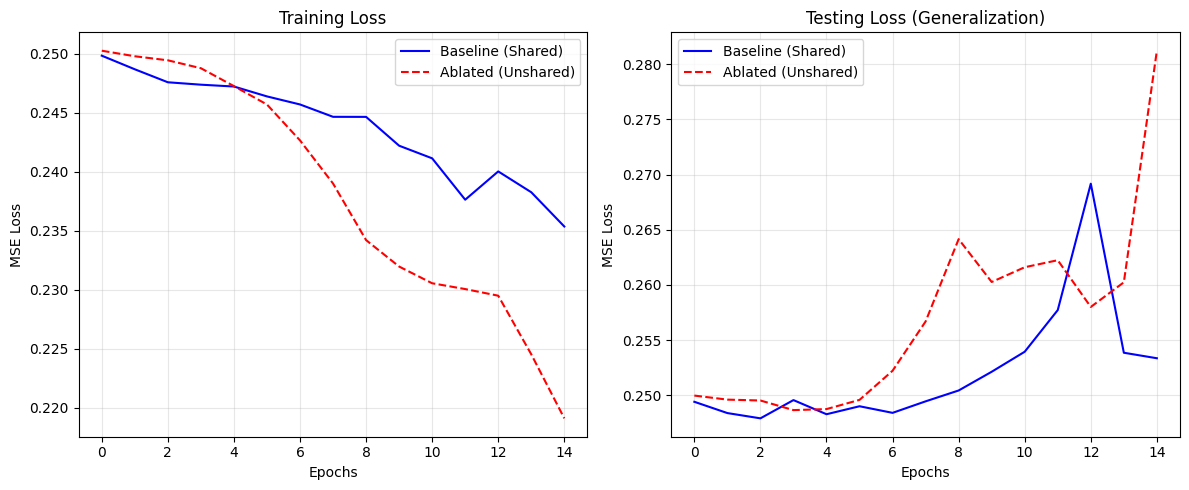

In [6]:
plt.figure(figsize=(12, 5))

# Đồ thị Train Loss
plt.subplot(1, 2, 1)
plt.plot(hist_base['train_loss'], label='Baseline (Shared)', color='blue')
plt.plot(hist_ablated['train_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Đồ thị Test Loss
plt.subplot(1, 2, 2)
plt.plot(hist_base['test_loss'], label='Baseline (Shared)', color='blue')
plt.plot(hist_ablated['test_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Testing Loss (Generalization)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Về Năng lực biểu diễn (Learning Capacity):** Mô hình Ablated (không chia sẻ trọng số) cho thấy tốc độ hội tụ trên tập huấn luyện (Train Loss) nhanh và sâu hơn đáng kể ($0.2191$ so với $0.2353$). Nguyên nhân là do việc sử dụng hai bộ Encoder độc lập làm tăng số lượng tham số của mạng, cung cấp cho mô hình "bộ nhớ" lớn hơn để khớp hoàn toàn với các dữ liệu nhiễu trong tập Train.

* **Về Tính năng Điều chuẩn (Regularization) của Mạng Siamese:** Mặc dù Baseline có Train Loss cao hơn, nhưng nó duy trì được Test Loss ở mức cực kỳ ổn định ($0.2533$). Trong trò chơi PvP đối kháng, tính chất của trò chơi là đối xứng (Đội A đánh Đội B cũng giống Đội B đánh Đội A nhưng đảo ngược kết quả). Việc kiến trúc Siamese ép hai đội phải đi qua chung một không gian trọng số đã vô tình tạo ra một "bộ điều chuẩn tự nhiên" (inductive bias), ngăn chặn mô hình học vẹt các yếu tố không mang tính chiến thuật.

* **Kết luận của Ablation Study:** Thực nghiệm này khẳng định quyết định thiết kế mạng Siamese của nhóm tác giả là hoàn toàn bắt buộc và chính xác. Nếu loại bỏ cơ chế chia sẻ trọng số, mạng neural sẽ bị vỡ cấu trúc và rơi vào trạng thái Overfitting nghiêm trọng (gap lên tới $0.0621$).